In [18]:
pip install pandas numpy scikit-learn xgboost matplotlib seaborn


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df = pd.read_csv("dataset.csv")

print(df.head())
print(df.info())

                              name  \
0     2024 Jeep Wagoneer Series II   
1  2024 Jeep Grand Cherokee Laredo   
2         2024 GMC Yukon XL Denali   
3       2023 Dodge Durango Pursuit   
4            2024 RAM 3500 Laramie   

                                         description   make           model  \
0  \n      \n        Heated Leather Seats, Nav Sy...   Jeep        Wagoneer   
1  Al West is committed to offering every custome...   Jeep  Grand Cherokee   
2                                                NaN    GMC        Yukon XL   
3  White Knuckle Clearcoat 2023 Dodge Durango Pur...  Dodge         Durango   
4  \n      \n        2024 Ram 3500 Laramie Billet...    RAM            3500   

   year    price                                             engine  \
0  2024  74600.0                            24V GDI DOHC Twin Turbo   
1  2024  50170.0                                                OHV   
2  2024  96410.0  6.2L V-8 gasoline direct injection, variable v...   
3  2023  468

In [21]:
df = df.drop(["name", "description"], axis=1)

In [22]:
df = pd.get_dummies(df, drop_first=True)

In [23]:
df.columns = df.columns.str.replace('[^A-Za-z0-9_]+', '', regex=True)

In [24]:
df = df.apply(pd.to_numeric, errors='coerce')

In [25]:
df = df.dropna()

In [26]:
print(df.dtypes)

# MUST be empty
print("Object columns:", df.dtypes[df.dtypes == 'object'])

year                                       int64
price                                    float64
cylinders                                float64
mileage                                  float64
doors                                    float64
                                          ...   
interior_color_WickerBeigeGlobalBlack       bool
interior_color_gray                         bool
drivetrain_FourwheelDrive                   bool
drivetrain_FrontwheelDrive                  bool
drivetrain_RearwheelDrive                   bool
Length: 884, dtype: object
Object columns: Series([], dtype: object)


In [27]:
X = df.drop("price", axis=1)
y = df["price"]

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

model.fit(X_train.values, y_train.values)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [30]:
y_pred = model.predict(X_test.values)

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 3779.964889977811
MSE: 44271451.35920345
RMSE: 6653.679535355114
R2 Score: 0.8330765535261723


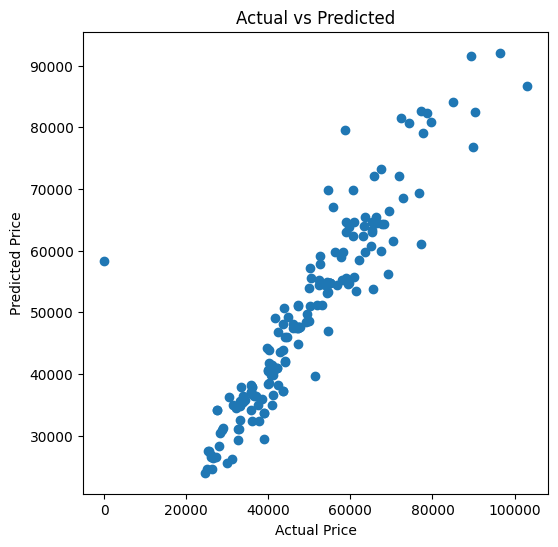

In [32]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

In [33]:
importances = model.feature_importances_

feat_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feat_df.head(10))

                        Feature  Importance
1                     cylinders    0.067890
10                   make_Dodge    0.054281
205  engine_24VGDIDOHCTwinTurbo    0.051285
285               fuel_Gasoline    0.048638
86          model_GrandCherokee    0.047001
18                    make_Jeep    0.046349
881  drivetrain_FrontwheelDrive    0.039032
798    interior_color_BlackOnyx    0.026068
53                model_Compass    0.025995
75             model_Expedition    0.025400


In [34]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

from sklearn.metrics import r2_score
print("Random Forest R2:", r2_score(y_test, y_pred_rf))

Random Forest R2: 0.8166992337652894


In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print results
print(" Evaluation Metrics for XGBoost Model")
print("--------------------------------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

 Evaluation Metrics for XGBoost Model
--------------------------------------
MAE : 3779.964889977811
MSE : 44271451.35920345
RMSE: 6653.679535355114
R2 Score: 0.8330765535261723


In [39]:
# Random Forest metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("\n Model Comparison")
print("---------------------")
print("XGBoost R2:", r2)
print("Random Forest R2:", r2_rf)


 Model Comparison
---------------------
XGBoost R2: 0.8330765535261723
Random Forest R2: 0.8166992337652894


In [40]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["XGBoost", "Random Forest"],
    "MAE": [mae, mae_rf],
    "RMSE": [rmse, rmse_rf],
    "R2 Score": [r2, r2_rf]
})

print(results)

           Model          MAE         RMSE  R2 Score
0        XGBoost  3779.964890  6653.679535  0.833077
1  Random Forest  4103.429827  6972.449037  0.816699


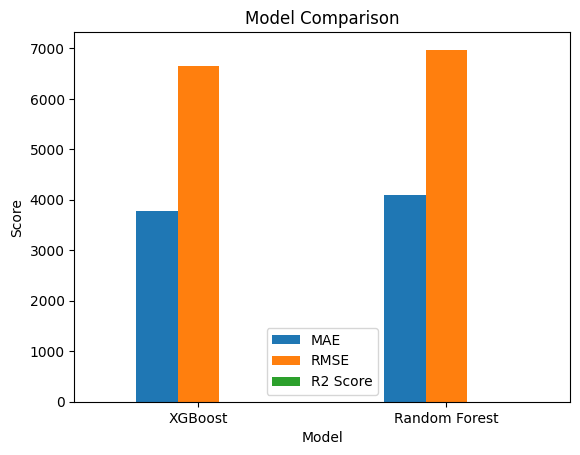

In [41]:
results.set_index("Model").plot(kind="bar")
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()